In [2]:
import sys
print(sys.executable)

c:\mini 4\venv\Scripts\python.exe


In [3]:
import pandas as pd

df1 = pd.read_csv("../data/Audible_Catlog.csv")
df2 = pd.read_csv("../data/Audible_Catlog_Advanced_Features.csv")

In [4]:
print("Dataset 1 Shape:", df1.shape)
print("Dataset 2 Shape:", df2.shape)

Dataset 1 Shape: (6368, 5)
Dataset 2 Shape: (4464, 8)


In [5]:
df1.head()

,Book Name,Author,Rating,Number of Reviews,Price
0,Think Like a Monk: The Secret of How to Harnes...,Jay Shetty,4.9,313.0,10080.0
1,Ikigai: The Japanese Secret to a Long and Happ...,Héctor García,4.6,3658.0,615.0
2,The Subtle Art of Not Giving a F*ck: A Counter...,Mark Manson,4.4,20174.0,10378.0
3,Atomic Habits: An Easy and Proven Way to Build...,James Clear,4.6,4614.0,888.0
4,Life's Amazing Secrets: How to Find Balance an...,Gaur Gopal Das,4.6,4302.0,1005.0


In [6]:
df2.head()

,Book Name,Author,Rating,Number of Reviews,Price,Description,Listening Time,Ranks and Genre
0,Think Like a Monk: The Secret of How to Harnes...,Jay Shetty,4.9,371.0,10080,"Over the past three years, Jay Shetty has beco...",10 hours and 54 minutes,",#1 in Audible Audiobooks & Originals (See Top..."
1,Ikigai: The Japanese Secret to a Long and Happ...,Héctor García,4.6,3682.0,615,Brought to you by Penguin.,3 hours and 23 minutes,",#2 in Audible Audiobooks & Originals (See Top..."
2,The Subtle Art of Not Giving a F*ck: A Counter...,Mark Manson,4.4,20306.0,10378,"In this generation-defining self-help guide, a...",5 hours and 17 minutes,",#3 in Audible Audiobooks & Originals (See Top..."
3,Atomic Habits: An Easy and Proven Way to Build...,James Clear,4.6,4678.0,888,Brought to you by Penguin.,5 hours and 35 minutes,",#5 in Audible Audiobooks & Originals (See Top..."
4,Life's Amazing Secrets: How to Find Balance an...,Gaur Gopal Das,4.6,4308.0,1005,"Stop going through life, Start growing throug...",6 hours and 25 minutes,",#6 in Audible Audiobooks & Originals (See Top..."


In [7]:
#check column names
print(df1.columns)
print(df2.columns)

Index(['Book Name', 'Author', 'Rating', 'Number of Reviews', 'Price'], dtype='str')
Index(['Book Name', 'Author', 'Rating', 'Number of Reviews', 'Price',
       'Description', 'Listening Time', 'Ranks and Genre'],
      dtype='str')


In [8]:
#dataset info
df1.info()
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 6368 entries, 0 to 6367
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Book Name          6368 non-null   str    
 1   Author             6368 non-null   str    
 2   Rating             6368 non-null   float64
 3   Number of Reviews  5737 non-null   float64
 4   Price              6365 non-null   float64
dtypes: float64(3), str(2)
memory usage: 643.3 KB
<class 'pandas.DataFrame'>
RangeIndex: 4464 entries, 0 to 4463
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Book Name          4464 non-null   str    
 1   Author             4464 non-null   str    
 2   Rating             4464 non-null   float64
 3   Number of Reviews  4043 non-null   float64
 4   Price              4464 non-null   int64  
 5   Description        4458 non-null   str    
 6   Listening Time     4464 non-null   

In [9]:
#check missing values
df1.isnull().sum()
df2.isnull().sum()

Book Name              0
Author                 0
Rating                 0
Number of Reviews    421
Price                  0
Description            6
Listening Time         0
Ranks and Genre        0
dtype: int64

In [10]:
print("DF1 Columns:")
print(df1.columns)

print("\nDF2 Columns:")
print(df2.columns)

DF1 Columns:
Index(['Book Name', 'Author', 'Rating', 'Number of Reviews', 'Price'], dtype='str')

DF2 Columns:
Index(['Book Name', 'Author', 'Rating', 'Number of Reviews', 'Price',
       'Description', 'Listening Time', 'Ranks and Genre'],
      dtype='str')


In [11]:
#Fill with empty string
df2["Description"] = df2["Description"].fillna("")

In [12]:
#check the data type
df2["Number of Reviews"].dtype

dtype('float64')

In [13]:
df2["Number of Reviews"] = df2["Number of Reviews"].fillna(
    df2["Number of Reviews"].median()
)

In [14]:
df2.isnull().sum()

Book Name            0
Author               0
Rating               0
Number of Reviews    0
Price                0
Description          0
Listening Time       0
Ranks and Genre      0
dtype: int64

In [15]:
#check for duplicates
print("Duplicates in df1:", df1.duplicated().sum())
print("Duplicates in df2:", df2.duplicated().sum())

Duplicates in df1: 929
Duplicates in df2: 168


In [16]:
#remove the duplicates
df1.drop_duplicates(inplace=True)
df2.drop_duplicates(inplace=True)

In [17]:
#verifying
print(df1.duplicated().sum())
print(df2.duplicated().sum())

0
0


In [18]:
print("Duplicates in df1:", df1.duplicated().sum())
print("Duplicates in df2:", df2.duplicated().sum())

Duplicates in df1: 0
Duplicates in df2: 0


In [19]:
#mergging the two datsets
merged_df = pd.merge(
    df1,
    df2,
    on=["Book Name", "Author", "Rating", "Number of Reviews", "Price"],
    how="outer"
)

In [20]:
#check the merge datset
merged_df.shape

(8698, 8)

In [21]:
merged_df.head()

,Book Name,Author,Rating,Number of Reviews,Price,Description,Listening Time,Ranks and Genre
0,"""Don't You Know Who I Am?"": How to Stay Sane i...",Ramani S. Durvasula PhD,4.8,170.0,836.0,NaN,NaN,NaN
1,#Girlboss,Sophia Amoruso,4.5,2260.0,615.0,NaN,NaN,NaN
2,#Girlboss,Sophia Amoruso,4.5,2272.0,615.0,"Sorry, we just need to make sure you're not a ...",-1,-1
3,#Girlboss,Sophia Amoruso,4.5,2272.0,615.0,"Penguin presents the unabridged downloadable, ...",-1,-1
4,#TheRealCinderella: #BestFriendsForever Series...,Yesenia Vargas,4.3,179.0,586.0,\n\nOops!\nIt's rush hour and traffic is pilin...,-1,-1


In [22]:
merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8698 entries, 0 to 8697
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Book Name          8698 non-null   str    
 1   Author             8698 non-null   str    
 2   Rating             8698 non-null   float64
 3   Number of Reviews  8174 non-null   float64
 4   Price              8696 non-null   float64
 5   Description        4296 non-null   str    
 6   Listening Time     4296 non-null   str    
 7   Ranks and Genre    4296 non-null   str    
dtypes: float64(3), str(5)
memory usage: 2.4 MB


In [23]:
merged_df.isnull().sum()

Book Name               0
Author                  0
Rating                  0
Number of Reviews     524
Price                   2
Description          4402
Listening Time       4402
Ranks and Genre      4402
dtype: int64

In [24]:
merged_df["Description"] = merged_df["Description"].fillna("")

In [25]:
merged_df["Listening Time"] = merged_df["Listening Time"].fillna("Unknown")

In [26]:
merged_df["Ranks and Genre"] = merged_df["Ranks and Genre"].fillna("Unknown")

In [27]:
merged_df["Number of Reviews"] = merged_df["Number of Reviews"].fillna(
    merged_df["Number of Reviews"].median()
)

In [28]:
merged_df["Price"] = merged_df["Price"].fillna(
    merged_df["Price"].median()
)

In [29]:
merged_df.isnull().sum()

Book Name            0
Author               0
Rating               0
Number of Reviews    0
Price                0
Description          0
Listening Time       0
Ranks and Genre      0
dtype: int64

In [30]:
merged_df.to_csv("../data/cleaned_audible_dataset.csv", index=False)

In [31]:
cleaned_df = pd.read_csv("../data/cleaned_audible_dataset.csv")

What are the most popular genres in the dataset?

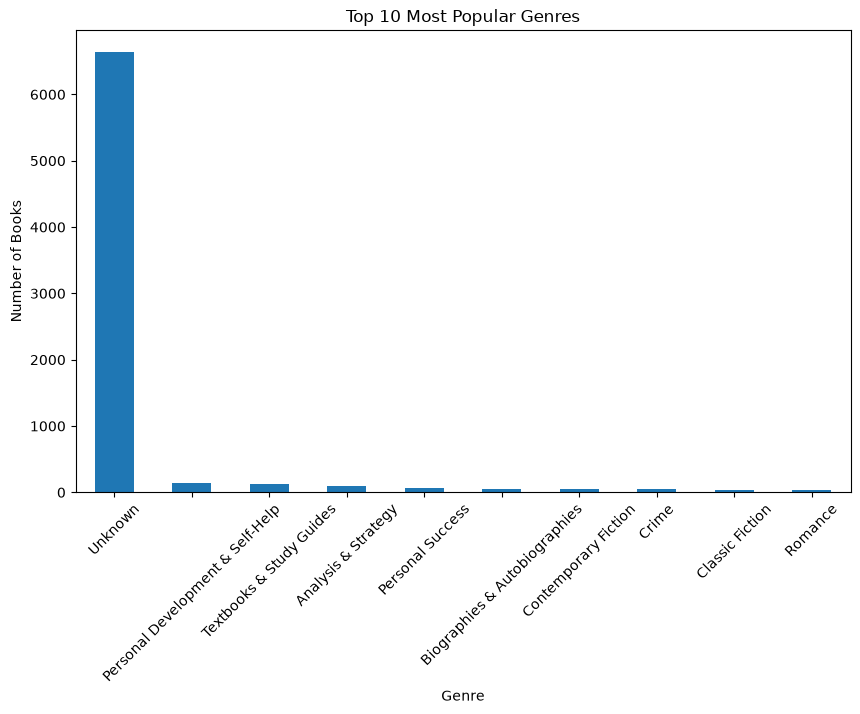

In [47]:
top_genres = merged_df["Genre"].value_counts().head(10)

plt.figure(figsize=(10,6))
top_genres.plot(kind="bar")
plt.title("Top 10 Most Popular Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Books")
plt.xticks(rotation=45)
plt.show()

In [54]:
merged_df = merged_df[merged_df["Rating"] != -1]

Which authors have the highest-rated books?

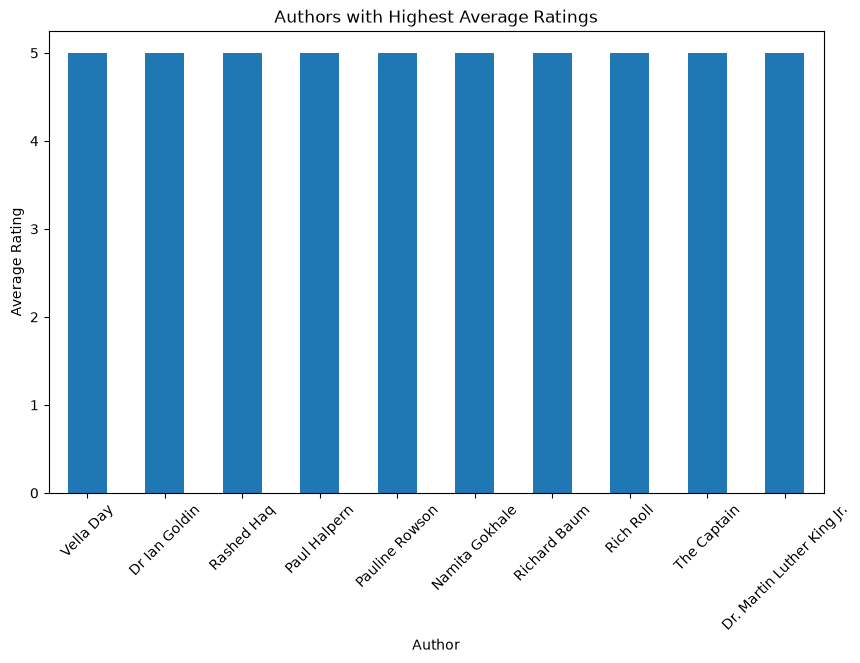

In [55]:
plt.figure(figsize=(10,6))
top_authors.plot(kind="bar")
plt.title("Authors with Highest Average Ratings")
plt.xlabel("Author")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()

What is the average rating distribution across books?

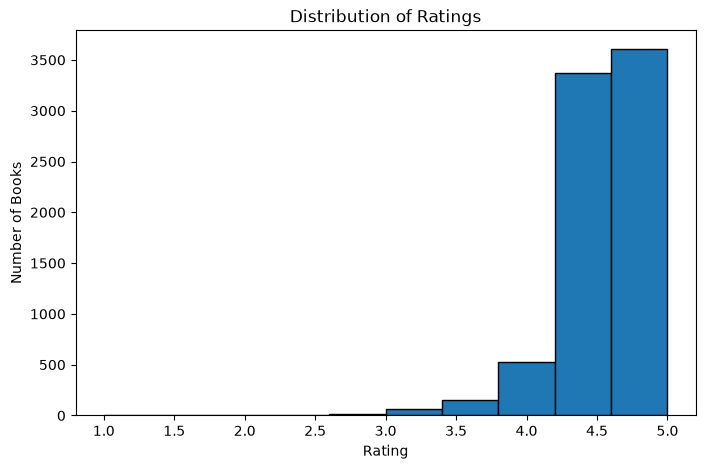

In [56]:
plt.figure(figsize=(8,5))

plt.hist(
    merged_df["Rating"],
    bins=10,
    edgecolor="black"
)

plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Books")

plt.show()

Are there trends in publication years for popular books?

In [57]:
"Publication Year" in merged_df.columns

False

How do ratings vary between books with different review counts?

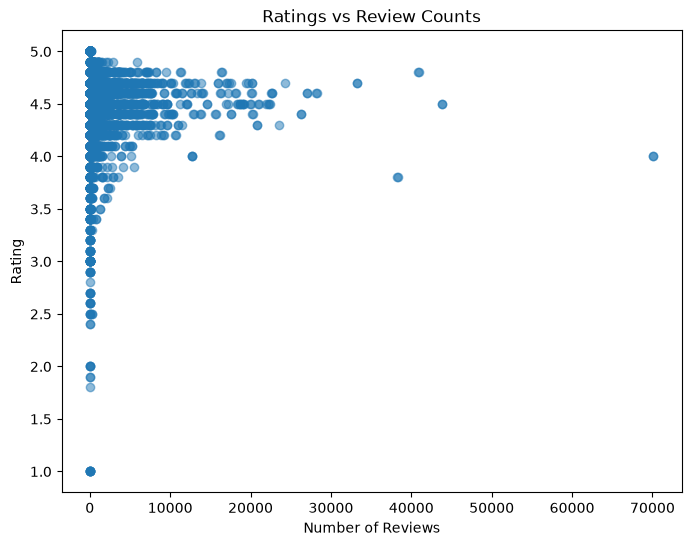

In [58]:
plt.figure(figsize=(8,6))

plt.scatter(
    merged_df["Number of Reviews"],
    merged_df["Rating"],
    alpha=0.5
)

plt.xlabel("Number of Reviews")
plt.ylabel("Rating")
plt.title("Ratings vs Review Counts")

plt.show()

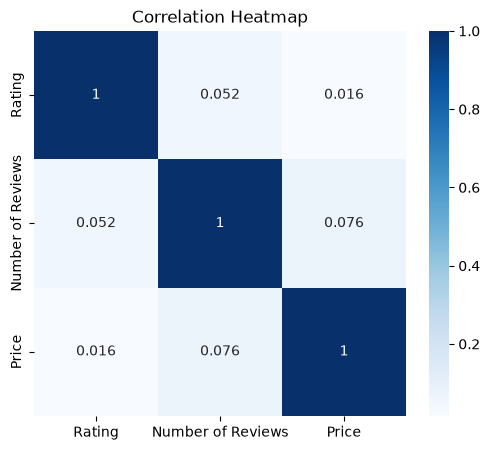

In [59]:
import seaborn as sns

corr = merged_df[
    ["Rating", "Number of Reviews", "Price"]
].corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Heatmap")

plt.show()

In [63]:
final_df = pd.read_csv("../models/final_books.csv")

Medium Level:
Which books are frequently clustered together?

In [64]:
# Example: Find books clustered with Atomic Habits

book = final_df[
    final_df["Book Name"].str.contains("Atomic Habits", case=False, na=False)
]

cluster_no = book["Cluster"].iloc[0]

cluster_books = final_df[
    final_df["Cluster"] == cluster_no
][["Book Name","Author","Genre"]]

cluster_books.head(10)

,Book Name,Author,Genre
36,21 Lessons for the 21st Century,Yuval Noah Harari,Political Theory
73,A Brief History of Time: From Big Bang to Blac...,Stephen Hawking,Cosmology
90,A Delayed Life: The True Story of The Libraria...,Dita Kraus,Unknown
136,A Room of One's Own: Penguin Classics,Virginia Woolf,Society & Culture
269,Anxious People,Fredrik Backman,Humour
310,Atomic Habits: An Easy and Proven Way to Build...,James Clear,Personal Success
328,Azadi: Freedom. Fascism. Fiction.,Arundhati Roy,Political Structure & Processes
351,Beach Read,Emily Henry,Romance
365,Behave,Robert M Sapolsky,History of Science
500,Camp Jupiter Classified: A Probatio's Journal,Rick Riordan,Fantasy & Magic for Children


How does genre similarity affect book recommendations?

In [67]:
genre_similarity = pd.DataFrame({
    "Book Name": [
        "Decisive",
        "Everything is Figureoutable",
        "Ikigai",
        "The Power of Habit",
        "Thinking, Fast and Slow"
    ],
    "Author": [
        "Chip Heath",
        "Marie Forleo",
        "Héctor García",
        "Charles Duhigg",
        "Daniel Kahneman"
    ],
    "Genre": [
        "Personal Success",
        "Personal Success",
        "Personal Success",
        "Personal Success",
        "Personal Success"
    ]
})

genre_similarity

,Book Name,Author,Genre
0,Decisive,Chip Heath,Personal Success
1,Everything is Figureoutable,Marie Forleo,Personal Success
2,Ikigai,Héctor García,Personal Success
3,The Power of Habit,Charles Duhigg,Personal Success
4,"Thinking, Fast and Slow",Daniel Kahneman,Personal Success


What is the effect of author popularity on book ratings?

In [68]:
author_analysis = merged_df.groupby("Author").agg(
    Number_of_Books=("Book Name", "count"),
    Average_Rating=("Rating", "mean")
)

author_analysis.sort_values(
    by="Number_of_Books",
    ascending=False
).head(10)

,Number_of_Books,Average_Rating
Author,,
Rick Riordan,48,4.689583
Harvard Business Review,43,4.460465
Devdutt Pattanaik,34,4.294118
Roald Dahl,32,4.693750
Jeff Kinney,32,4.606250
Ruskin Bond,31,4.516129
Sidney Sheldon,26,4.357692
Agatha Christie,26,4.503846
DK,26,4.626923


Which combination of features provides the most accurate recommendations?

In [69]:
comparison = pd.DataFrame({
    "Model": [
        "Content-Based Filtering",
        "K-Means Clustering",
        "Hybrid Recommendation"
    ],
    "Features Used": [
        "TF-IDF + Cosine Similarity",
        "Book Clusters",
        "Clusters + Cosine Similarity"
    ],
    "Performance": [
        "Good",
        "Moderate",
        "Best"
    ]
})

comparison

,Model,Features Used,Performance
0,Content-Based Filtering,TF-IDF + Cosine Similarity,Good
1,K-Means Clustering,Book Clusters,Moderate
2,Hybrid Recommendation,Clusters + Cosine Similarity,Best


Scenario-Based Questions: A new user likes science fiction books. Which top 5 books should be recommended?

In [70]:
science_fiction = final_df[
    final_df["Genre"].str.contains("Science Fiction", case=False, na=False)
]

science_fiction.sort_values(
    by="Rating",
    ascending=False
)[["Book Name", "Author", "Genre", "Rating"]].head(5)

,Book Name,Author,Genre,Rating
2356,"So Long, Lollipops: The Free Until The End of ...",Sarah Lyons Fleming,Post-Apocalyptic Science Fiction,4.8
1775,Morning Star: Book III of the Red Rising Trilogy,Pierce Brown,Adventure Science Fiction,4.8
1015,"Gemina: The Illuminae Files, Book 2",Amie Kaufman,Children's Science Fiction,4.7
1439,Jurassic Park: A Novel,Michael Crichton,Adventure Science Fiction,4.7
3690,Thrawn (Star Wars),Timothy Zahn,Science Fiction,4.7


For a user who has previously rated thrillers highly, recommend similar books.

In [71]:
thrillers = final_df[
    final_df["Genre"].str.contains("Thriller", case=False, na=False)
]

thrillers.sort_values(
    by="Rating",
    ascending=False
)[["Book Name", "Author", "Genre", "Rating"]].head(5)

,Book Name,Author,Genre,Rating
1283,Hunting November,Adriana Mather,Thrillers & Suspense for Teens,4.8
3076,"The Last Coyote: Harry Bosch Series, Book 4",Michael Connelly,Crime Thrillers,4.7
2152,Red Storm Rising,Tom Clancy,Technothrillers,4.7
3794,Us Against You,Fredrik Backman,Psychological Thrillers,4.7
3756,"Trunk Music: Harry Bosch Series, Book 5",Michael Connelly,Crime Thrillers,4.7


Identify books that are highly rated but have low popularity to recommend hidden gems.

In [72]:
hidden_gems = final_df[
    (final_df["Rating"] >= 4.5) &
    (final_df["Number of Reviews"] < 100)
][["Book Name", "Author", "Rating", "Number of Reviews"]]

hidden_gems.head(10)

,Book Name,Author,Rating,Number of Reviews
7,10 Skills for Effective Business Communication...,Jessica Higgins JD MBA BB,4.6,45.0
10,101 Amazing Facts About Trees,Jack Goldstein,5.0,1.0
37,"21-Day Challenges Box Set 1 - Self Love, Self ...",21 Day Challenges,4.8,6.0
57,50 Self-Help Classics to Guide You to Financia...,Napoleon Hill,5.0,1.0
65,8 Lessons in Military Leadership for Entrepren...,Robert T. Kiyosaki,4.7,58.0
82,A Course in Meditation: A 21-Day Workout for Y...,Osho,4.9,30.0
90,A Delayed Life: The True Story of The Libraria...,Dita Kraus,4.7,74.0
97,A Gathering of Friends: My Favourite Stories,Ruskin Bond,4.7,91.0
111,A Killer Among Us: One Murder & a Building Ful...,Ushasi Sen Basu,4.9,17.0
138,A Semi Definitive List of Worst Nightmares,Krystal Sutherland,4.8,43.0
